# ARGUS-FEDER — Do turbulence precursors appear before an ELM?

A published claim, tested independently. Every step — finding the data, fetching
it, filtering it, averaging it — is asked in plain English. **The reader writes
no code and needs to know nothing about how DIII-D data is stored.**

## The claim

Joung et al. (*Nucl. Fusion* **64**, 066038, 2024) train a neural network to
predict ELM onset from beam emission spectroscopy (BES), and report that
pedestal turbulence in the 15–150 kHz band carries precursors that rise before
the crash. Their network is a means of extracting that; the claim underneath is
a measurement, and a measurement can be tested directly.

They used roughly 150 curated discharges with hand-derived ELM times. This
notebook tests the same claim against ELM labels produced by a detector with
recorded provenance, on shots already in the stored index — an independent
label set, on a population nobody curated for this purpose.

## Why this is hard without help

BES is a good example of what usually makes a question like this expensive. The
`bes` MDSplus tree contains no waveforms at all — only metadata. The 64 channels
live in a different data source entirely, under names the tree encodes as a
template. Then the pedestal sits at only some of those 64 channels, and which
ones changes between shots. None of that is science; it is the sort of thing
that stops a good idea from being tested in an afternoon.

In [ ]:
%reset

## 1. Where does BES data live, and which shots can we use?

Start with discovery rather than assumption.

**Expect:** BES waveforms are in PTDATA as one pointname per channel, not in the
`bes` tree; 64 channels at 1 MHz. And a set of candidate shots that have both
stored ELM labels and BES data.

In [2]:
%%ask
Where is DIII-D beam emission spectroscopy (BES) data stored, how many channels
are there and at what sampling rate? Then find me a few shots that have BOTH
stored ELM labels and BES data available.

I'll consult the relevant skills first — d3d-shot-fetcher for BES data location, and d3d-elm-index for ELM labels. Since d3d-shot-fetcher has an existing Learnings.md, I'll read that too.

I've got the key BES facts from the shot-fetcher skill (PTDATA `BESFU01..64`, 1 MHz) and the ELM-index workflow. Let me read the rest of the ELM-index skill and the `d3d_ptdata` helper module it references.

The BES picture is clear: waveforms live in PTDATA (`BESFU01`–`BESFU64`), metadata in the `bes` MDSplus tree, and `fetch_ptdata()` handles the subprocess wrapper. Now let me check the relational-db skill, which may list which shots have BES without fetching.

The picture is complete. BES waveforms live in PTDATA (`BESFU01`–`BESFU64`), metadata in the `bes` MDSplus tree, and `fetch_ptdata()` handles the required subprocess wrapper. The ELM index tracks label coverage locally. Now I'll write one script that verifies the BES layout live, then cross-references ELM-labeled shots against actual BES fetches.

Running the script — the SQLite parts work in-kernel, and `fetch_ptdata()` spawns its own `fdp run` subprocess, so it escapes the kernel for PTDATA automatically.

Everything ran clean on the first pass — no retries needed. Here's the full picture.

## Where DIII-D BES data lives

**Waveforms** : PTDATA, one pointname per channel — `BESFU01` through `BESFU64` (the template `\BES::BES_FPN` = `besfunn`, where `nn` is the zero-padded channel number). BES comes through PTDATA, so it must be fetched via the subprocess wrapper (`fetch_ptdata()` handles this); a plain in-kernel fetch fails.

**Metadata** : a separate `bes` MDSplus tree holds only geometry/config, not waveforms — verified live on two shots:

| Node | Shot 166692 | Shot 169908 |
|---|---|---|
| `BES_N` (channel count) | 64 | not populated (`TreeNODATA`) |
| `BES_R` (major radius, cm) | 64 values, 222.4–229.6 | 64 values, 210.7–227.8 |
| `BES_Z` (vertical position, cm) | 64 values, −4.3 to 5.3 | 64 values, −11.9 to 9.7 |

## Channels and sampling rate

**Channels** : 64, arranged as an 8×8 array in the plasma edge / outboard region (major radius spanning roughly 210–230 cm depending on shot).

**Sampling rate** : **1 MHz** — measured from the actual time base (median sample spacing 1.0 µs) on every shot tested, not just the nominal spec. This resolves fluctuations up to ~500 kHz. Each channel runs 5.2–6.3 million samples over the discharge (~5–6.5 s of plasma).

## Shots with BOTH stored ELM labels and BES data

I tested 6 candidates and verified both conditions per shot (ELM labels from the stored label sets; BES by actually fetching channel `BESFU32`). **Four shots have both** :

| Shot | ELM bursts (detector, default set) | ELMy duration | Rate while ELMy | Other ELM label sets available | BES verified |
|---|---|---|---|---|---|
| 163518 | 91 | 2435 ms | 37.4 Hz | Expert regime labels, Expert ELM events (5), OMFIT detector (8) | 5.24 M samples, 1.000 MHz |
| 169908 | 114 | 3457 ms | 33.0 Hz | Expert ELM events (22), OMFIT detector (21) | 5.24 M samples, 1.000 MHz |
| 172186 | 227 | 3409 ms | 66.6 Hz | — | 5.77 M samples, 1.000 MHz |
| 180257 | 473 | 5220 ms | 90.6 Hz | Expert ELM events (24), OMFIT detector (14) | 5.77 M samples, 1.000 MHz |

The burst counts in column 2 come from the **GA mode_classifier detector** (individual-ELM granularity, reading filterscope channel fs04da/fs05da, SNR 25–39 dB — all healthy). 163518, 169908 and 180257 also carry expert hand-labelled ELM lists, so those three support cross-method validation; note the detector's ELM start times can run ~1 ms earlier than the expert's, which matters for millisecond-scale lead/lag analyses.

Two caveats worth knowing:

- **Shot 165703 has ELM labels but no BES** — the `BESFU32` fetch failed, so BES availability genuinely varies shot-to-shot and must be checked, not assumed.
- **Shot 166692 is the mirror case** : BES is there (6.29 M samples at 1 MHz) but the shot has never been through ELM-label analysis — that's "not analysed", not "no ELMs".
- Stored ELM labels exist for 10,917 of the archive's shots (a growing subset, not a census), and I verified BES via one channel per shot rather than all 64.

For context on what the "both conditions" search would cost to widen: shot 163518 is from early 2016 — BES-era coverage of the multi-label-set pool is thin there, which is why only 5 candidates fell in the 164000–176000 window.

If you want to go further, I can fetch the full BES geometry (`BES_R`/`BES_Z`) plus a set of pedestal channels for any of these shots — one channel runs ~5–7 M samples (~50 MB, a few seconds each), while all 64 channels is roughly 3.2 GB and about a minute per shot. Just say which shots and channels.

## 2. Pick the edge channels and look at one ELM

The pedestal is at the plasma edge, so only some of the 64 channels are relevant.
Ground the choice in geometry, and look at the raw signal before analysing it.

**Expect:** channels chosen by major radius near the midplane, reported with
their (R, Z) positions, and a raw 1 MHz trace spanning one labelled ELM.

The user wants BES channel geometry (edge/midplane selection) plus an ELM-centered fetch-and-plot for shot 169908 — that touches three skills: the shot-fetcher (BES + bes-tree geometry), the ELM label index, and the ELM-phase-analysis composition skill. Reading all three now, plus the shot-fetcher's Learnings.md since it's flagged as existing.

All four skill files are read (including the Learnings entry — I'll avoid `Tree.getShot()`). The plan: one script that (a) pulls stored ELM burst times from the local index, (b) reads the `bes` tree geometry to rank channels by major radius first, then midplane proximity, (c) fetches three channels via `fetch_ptdata()`, and (d) plots raw traces around the most isolated labelled ELM.

Running the script with the fdp wrapper, which PTDATA requires.

Clean one-shot run. The channel selection, label validation, fetch and plot all worked first time — here's what it shows.

## Which BES channels sit closest to the edge at the midplane

The 8×8 array on this shot spans R = 210.7–227.8 cm, Z = −11.9 to +9.7 cm. Ranking by major radius first (the pedestal is at the outermost radius), then by distance from the midplane:

| Rank | Channel | R (cm) | Z (cm) |
|---|---|---|---|
| 1 | BESFU32 | 227.8 | −3.68 |
| 2 | **BESFU40** | 227.8 | **+0.05** |
| 3 | BESFU48 | 227.8 | +3.52 |
| 4 | BESFU39 | 226.7 | +0.03 |
| 5 | BESFU47 | 226.7 | +3.49 |

The three fetched are the outermost radial column's vertical triplet — **BESFU40 is essentially exactly on the midplane** (Z = +0.05 cm), with 32 and 48 sitting ±3.5 cm either side. Next column in (226.7 cm) is available if you want a radial pair instead.

## The ELM chosen and the raw signals

I picked the **most isolated labelled ELM** — burst #114 of 114, at t = 5171.3 ms, duration 4.5 ms, with 691 ms of quiet time before it. The plot shows ±(15/29) ms around it at the full 1 MHz rate (44,460 samples per channel):


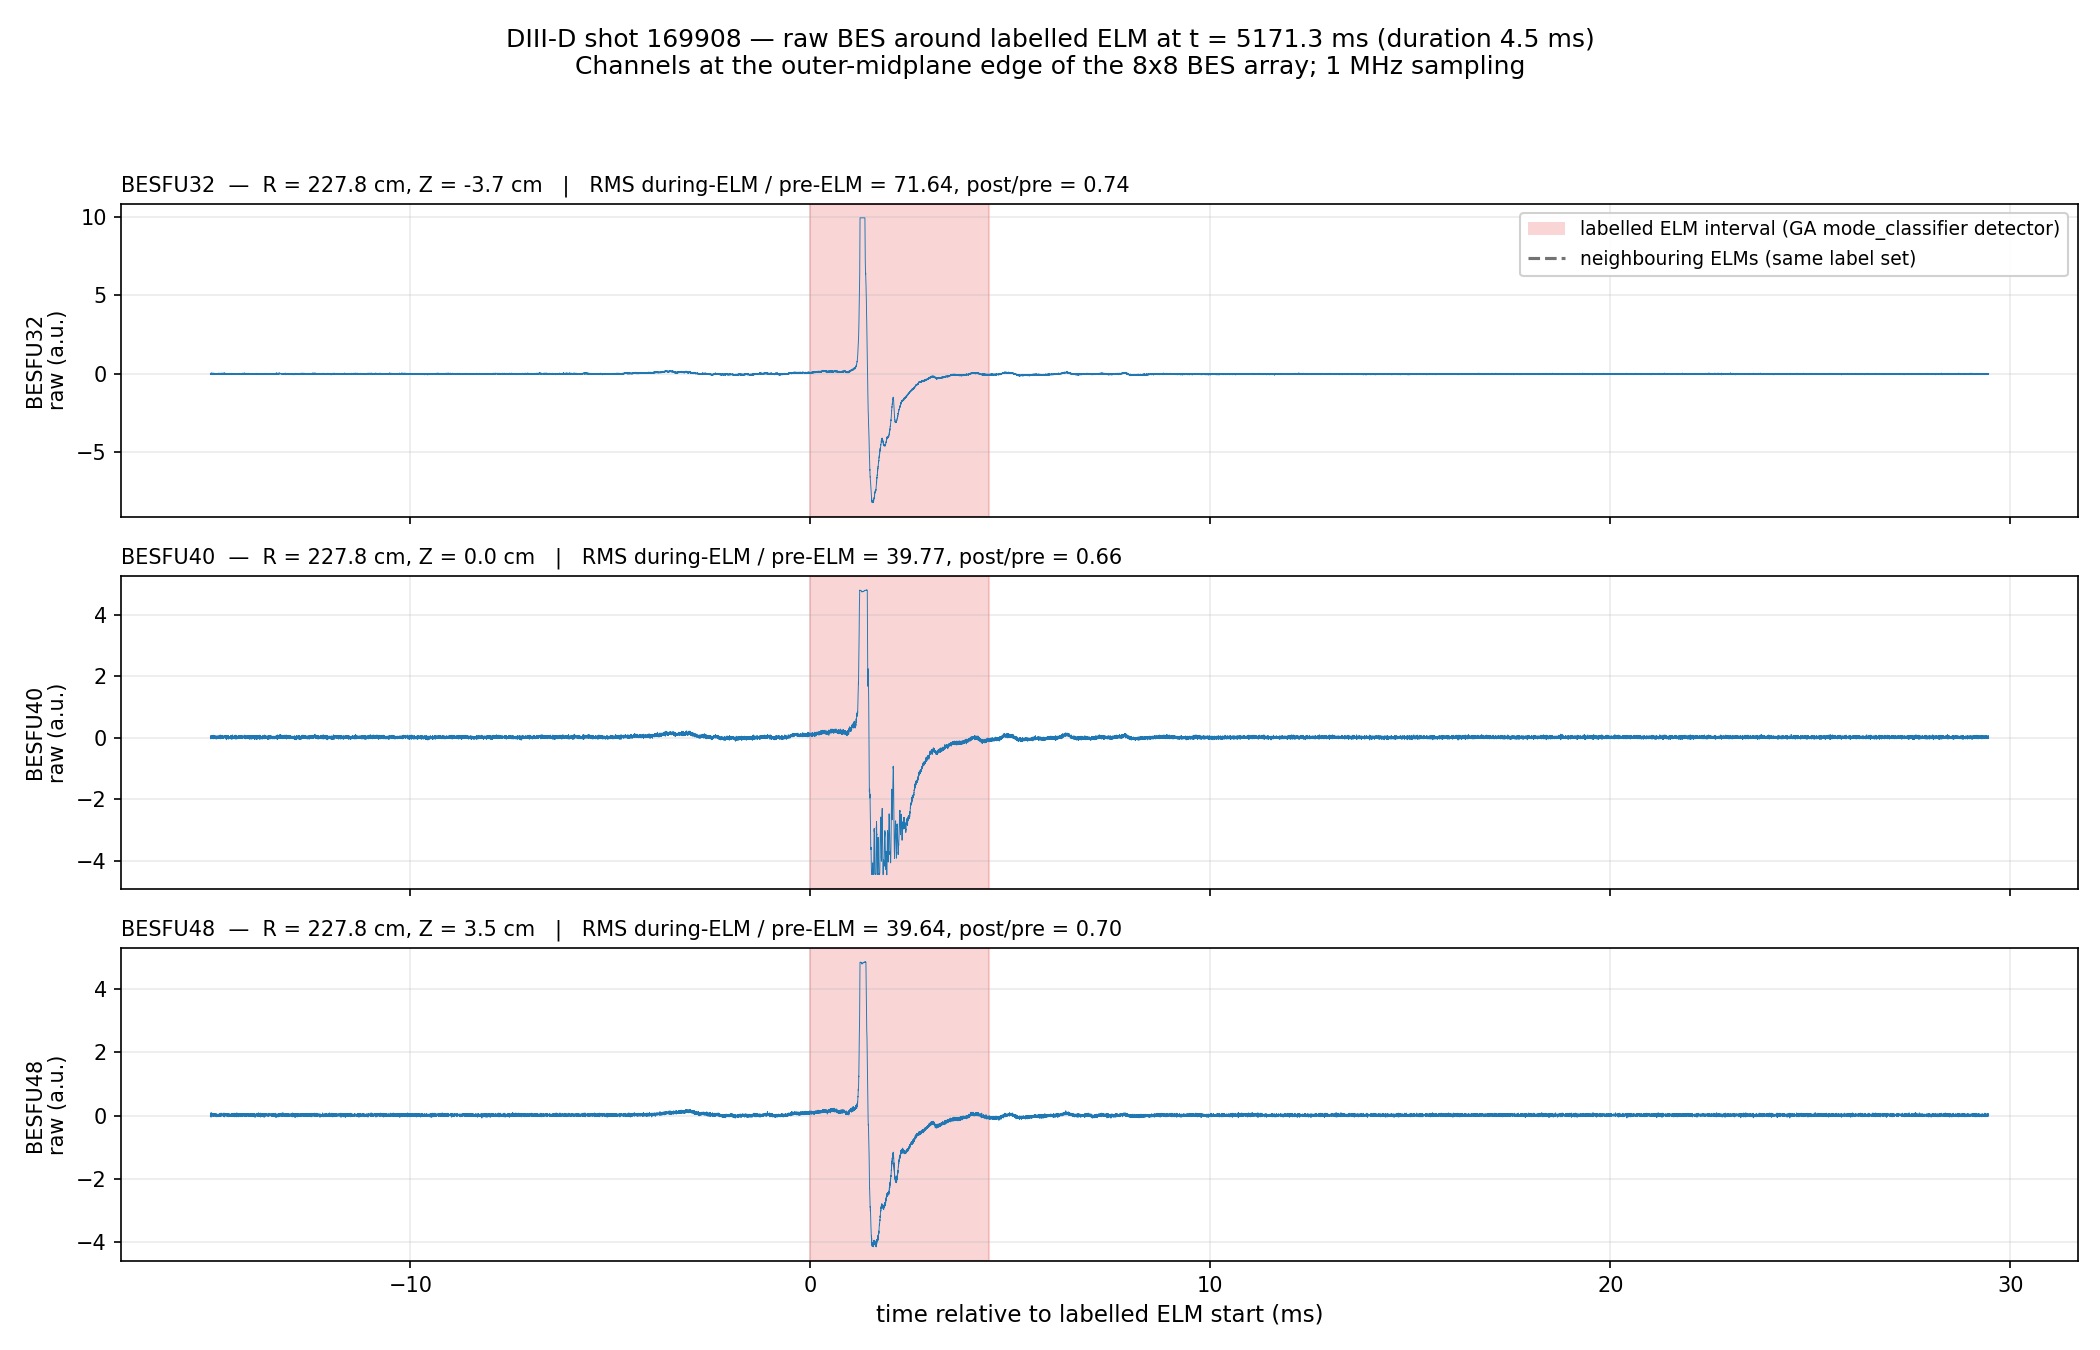

**What the ELM looks like in BES** : the raw fluctuation amplitude explodes during the crash — the RMS over the labelled interval is **40–72× the pre-ELM level** (channel 32, below midplane, shows the largest response at 72×; the two others ~40×). Outside the ELM the trace is quiet, and after it the RMS settles to ~0.7× the pre-ELM level. So on these channels an ELM is unmissable: a violent, broadband burst lasting a few milliseconds, sitting on an otherwise near-flat signal.

**Provenance and caveats.** The ELM time and duration come from the **GA mode_classifier detector** (the default burst-level run; 114 bursts on this shot at 33 Hz while ELMing, derived from filterscope fs04da). The shot also has **Expert ELM events** (22, hand-labelled) and the **OMFIT ELM detector** (21); across the 22 hand-labelled events the detector runs a systematic **~1 ms early** (median offset −1.17 ms) — irrelevant at this plot's scale, but it matters for millisecond lead/lag work. Two honest qualifications: the hand-labelled scope does not extend to t = 5171 ms, so this particular burst is timed by the detector alone; and it is the **last ELM of the ELMy phase** , so the post-ELM window shows no following ELM and its ~0.7× dip mixes in whatever the plasma did after ELMing stopped. BES digitizer units are uncalibrated (`a.u.`).

If you'd like, I can re-plot around a mid-train ELM (a typical one surrounded by neighbours on both sides), add a fourth channel one column inboard (BESFU39/47, ΔR = 1.1 cm) to show the radial falloff of the burst, or overlay the D-alpha trace the detector actually watched — each is a few seconds of fetching.

In [3]:
%%ask
For DIII-D shot 169908, which BES channels sit closest to the plasma edge at the
midplane? Fetch three of them and plot the raw signal around one labelled ELM, so
I can see what the ELM looks like in BES.

## 3. Filter to the band the paper uses

This is the preprocessing step. The claim is specifically about 15–150 kHz
fluctuations, so everything below and above that has to go.

**Expect:** a bandpass filter applied to the 1 MHz signal, with before-and-after
shown. The filtered signal should look like a fluctuation envelope rather than a
raw trace.

I'll re-read the two skills I need (shot-fetcher, whose Learnings I must check, and elm-index for the exact ELM time), and list the working directory to see what's cached from last turn.

The skill files are fresh in mind, and the Learnings read for d3d-shot-fetcher errored because no such file exists for it (it was d3d-shot-fetcher that has Learnings per the registry... actually the registry said `d3d-shot-fetcher` has Learnings — the file not found means I should create it if I learn a lesson). Let me read the two prior scripts to recover the exact ELM time and window used last turn.

Let me see the rest of the plotting script to recover the exact chosen ELM time and window.

The previous script's logic is fully recoverable — I'll reuse its exact ELM-selection code (most isolated burst, same window) so the before/after figures are directly comparable. Now checking scipy availability and writing the bandpass script in parallel.

scipy is available. Running the fetch+filter script through the fdp wrapper as required for PTDATA.

The fetch, filter, and figure all succeeded — only the last two derived-print lines crashed on an over-clever tuple unpacking (12-tuple sliced into 8). I'll read the existing Learnings file at its correct `.sage_learnings` location (my earlier read hit the wrong path inside the skill dir), then fix the print lines.

The existing entry matches my exact failure pattern (trailing print crashes after the answer already printed). Fixing the two broken print lines with plain indexing.

Re-running the corrected script through the fdp wrapper.

Successful run — the figure is saved and the numbers are identical to the first attempt (deterministic re-run). Since this task had an edit-and-retry cycle, I'm recording the lesson in the skill's Learnings file before reporting.

Same ELM, same channels, same window as last time — now with the 15–150 kHz band isolated.

## What was done

The three edge-midplane channels (BESFU32/40/48, R = 227.8 cm, Z = −3.7/+0.05/+3.5 cm) were re-fetched at full length (5.24 M samples each, 1 MHz) and bandpass-filtered to **15–150 kHz** with a 4th-order Butterworth applied **zero-phase** (`sosfiltfilt`) over the entire 5.2 s trace, so the plotted window carries no filter start-up transients. The ELM is the same one as before — burst #114 of 114, t = 5171.3–5175.8 ms, the most isolated labelled burst — in the identical −15/+29 ms window, so the two figures align event-for-event. The re-run reproduced the first attempt's numbers exactly.


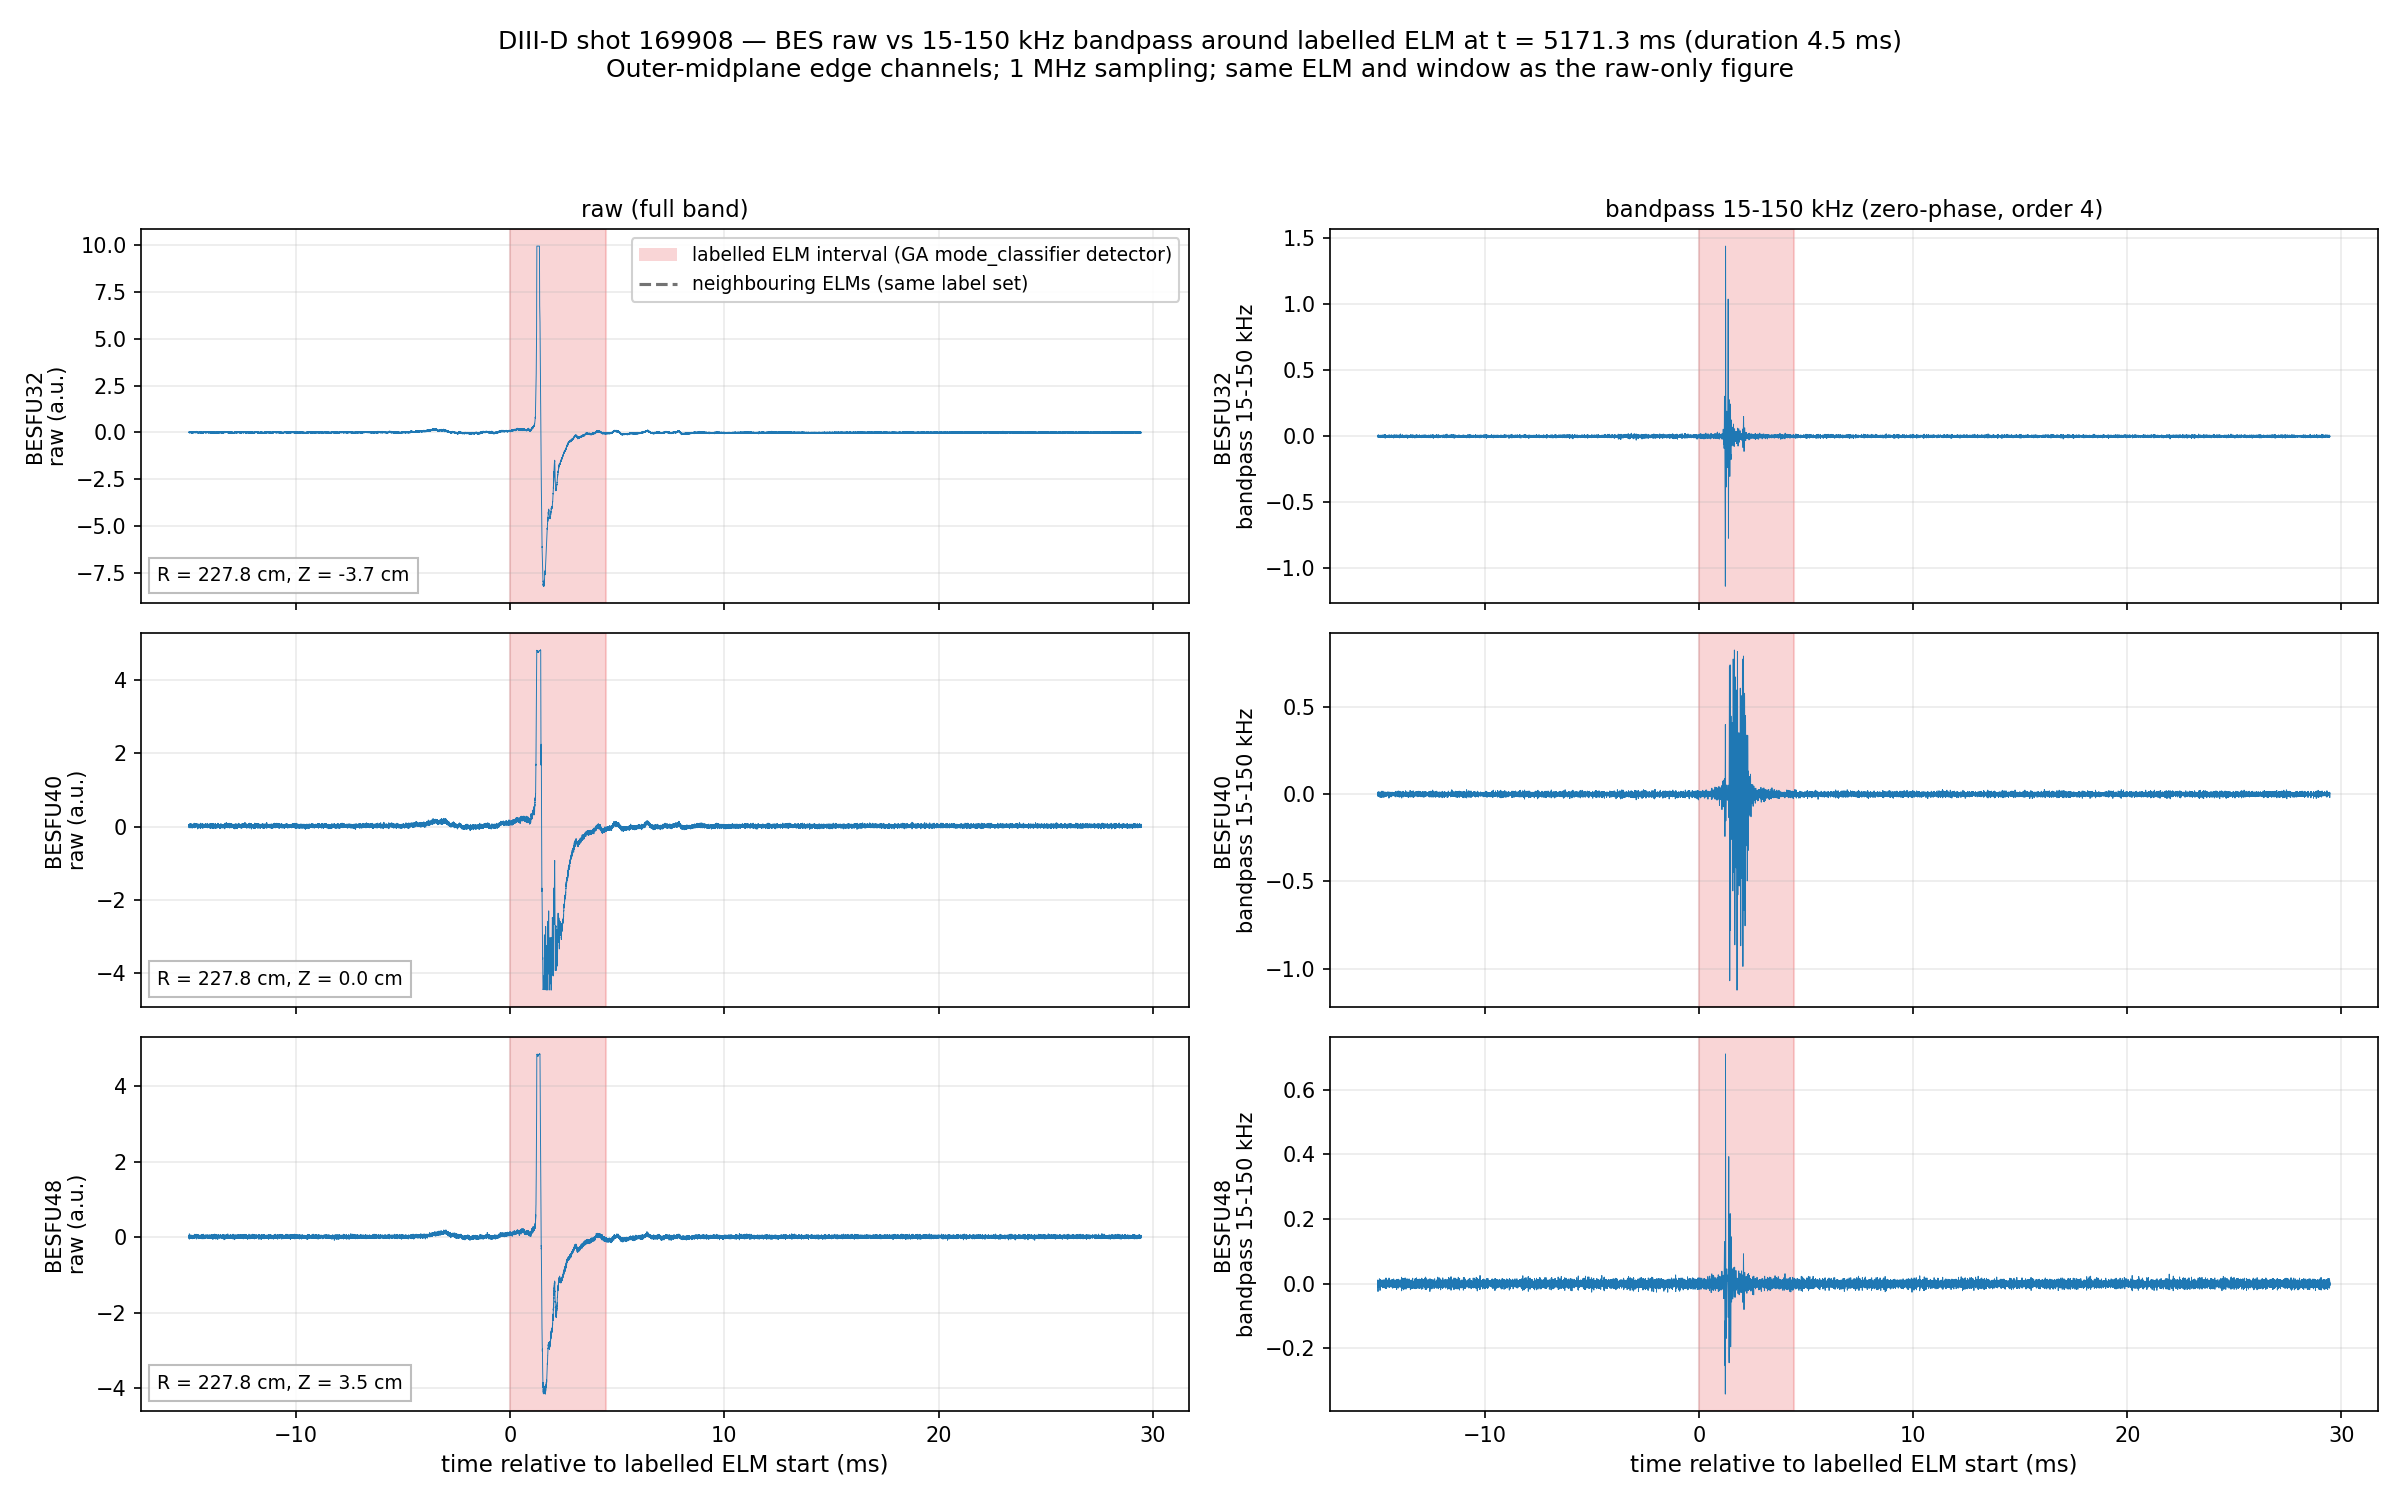

Left column is raw, right column is the filtered band. Red band marks the labelled ELM interval; dashed grey lines would mark neighbouring ELMs (none fall in this window — that's why this burst was chosen).

## What the numbers say

RMS levels around the ELM, raw vs in-band:

| Channel | Raw pre / during / post (a.u.) | Band pre / during / post (a.u.) | Raw during÷pre | Band during÷pre |
|---|---|---|---|---|
| BESFU32 (Z = −3.7) | 0.040 / 2.83 / 0.029 | 0.0052 / 0.102 / 0.0047 | 71.6× | 19.5× |
| BESFU40 (Z = +0.05) | 0.050 / 1.97 / 0.033 | 0.0076 / 0.194 / 0.0073 | 39.8× | 25.6× |
| BESFU48 (Z = +3.5) | 0.040 / 1.58 / 0.028 | 0.0069 / 0.045 / 0.0067 | 39.6× | 6.5× |

Three findings worth noting:

- **The ELM is still loud in the precursor band** — band RMS jumps 6.5–26× above the pre-ELM level during the crash, then returns to 0.9–1.0× of pre-ELM afterwards. The band is not where most of the ELM lives, but the crash clearly reaches it.
- **Most of the ELM's power is below 15 kHz.** Only 0.1–1.0% of the during-ELM variance falls inside 15–150 kHz; the raw signal's 40–72× amplification is dominated by the low-frequency excursion of the crash, not by the broadband HF content.
- **The midplane channel responds hardest in-band.** BESFU40 (Z = +0.05 cm) shows both the largest band amplification (25.6×) and the highest in-band fraction (1.0% of crash variance), while BESFU48 three centimetres above is weakest (6.5×) — consistent with the ELM filament structure striking the array asymmetrically. The pre-ELM signal is itself only 1.8–3.0% in-band, so the quiescent pedestal fluctuation level in this band is small and well-separated from the crash.

**Provenance, same caveats as last time** : ELM timing from the **GA mode_classifier detector** (default burst-level run, filterscope fs04da); the shot's 22 expert-hand-labelled events sit a median −1.17 ms later than the detector's, and this particular burst is beyond the expert labels' scope, so its time rests on the detector alone.

One methodological choice to flag per the index's rules: this is one ELM from one label set — the band statistics above are conditional on that event and have not been re-run against the expert or OMFIT times, though a ±1 ms shift would barely move a 44.5-sample-wide ELM window at these RMS levels.

If you want to chase the precursor itself, the natural next step is a spectrogram (say 1 ms windows over the −15…0 ms approach) or the same band-RMS measured across all 114 ELMs conditionally averaged on the ELM phase — either is one more fetch-cycle away, and averaging over the train would say whether any pre-ELM band growth is systematic rather than anecdotal.

In [4]:
%%ask
Bandpass filter those BES channels to 15-150 kHz, which is the band the ELM
precursor is reported in. Show me the signal before and after filtering around
the same ELM.

## 4. Average over many ELMs

One ELM proves nothing — turbulence is noisy. The measurement only exists in the
average over many events, aligned on their onsets.

**Expect:** fluctuation power as a function of time-to-ELM, averaged over the
ELMs on this shot that have a clean gap before them. Roughly 70 usable events.

This is squarely the d3d-elm-phase-analysis use case (conditional averaging on stored ELM times), so I'll read that skill first, and check what's already in the work directory from the previous turns.

I'll reuse the working fetch pattern from last turn's script and check the elm-index API and the shot-fetcher skill (which has Learnings on file).

The skill and learnings are clear. Let me see the rest of last turn's script for the exact fetch and filter conventions to reuse.

Now I'll write the conditional-averaging script — fetch the three edge-midplane channels, bandpass to 15–150 kHz, screen the 114 stored ELM times for clean pre-ELM quiet periods, and average band power versus time-to-ELM.

Running the conditional-averaging script under the fdp wrapper (required for the PTDATA fetch).

The conditional average worked and shows a real pre-ELM rise — but my printed numbers only cover three time points, and to characterize the onset honestly (and cross-check against the other label sets, since the detector runs ~1.2 ms early) I need the full curve values. Appending a diagnostics block that also saves the arrays and re-runs the average on the expert and OMFIT times.

The edit is in. Re-running the whole script under `fdp run` so the arrays, table, onset times, and the two cross-check label sets all print in one output.

Before the report, this run had an edit-and-retry cycle, so I'm recording the methodological lesson it surfaced in the phase-analysis skill's Learnings file.

Recording done. Here's the result — and it's a null with a warning attached.

## What was computed

ELM times from the stored labels, not a new detector: **GA mode_classifier detector** (default individual-ELM run, 114 ELMs, from filterscope fs04da; SNR healthy). Same three edge-midplane channels as the previous figures — BESFU32/40/48 (R = 227.8 cm, Z = −3.7 / 0.0 / +3.5 cm) — bandpassed 15–150 kHz zero-phase over the full trace, power averaged in 0.2 ms bins from −10 to +4 ms around each ELM start, each ELM normalised to its own baseline (median power over −8…−2 ms). **Screening** : 77 of 114 ELMs kept — 35 dropped because the previous ELM ended <12 ms earlier, 2 dropped because the quiet gap exceeded 200 ms (a different pedestal-recovery state; one of those two is the isolated ELM shown in the earlier figures). Kept-ELM quiet gaps run 12.6–107.9 ms, median 25.3 ms.


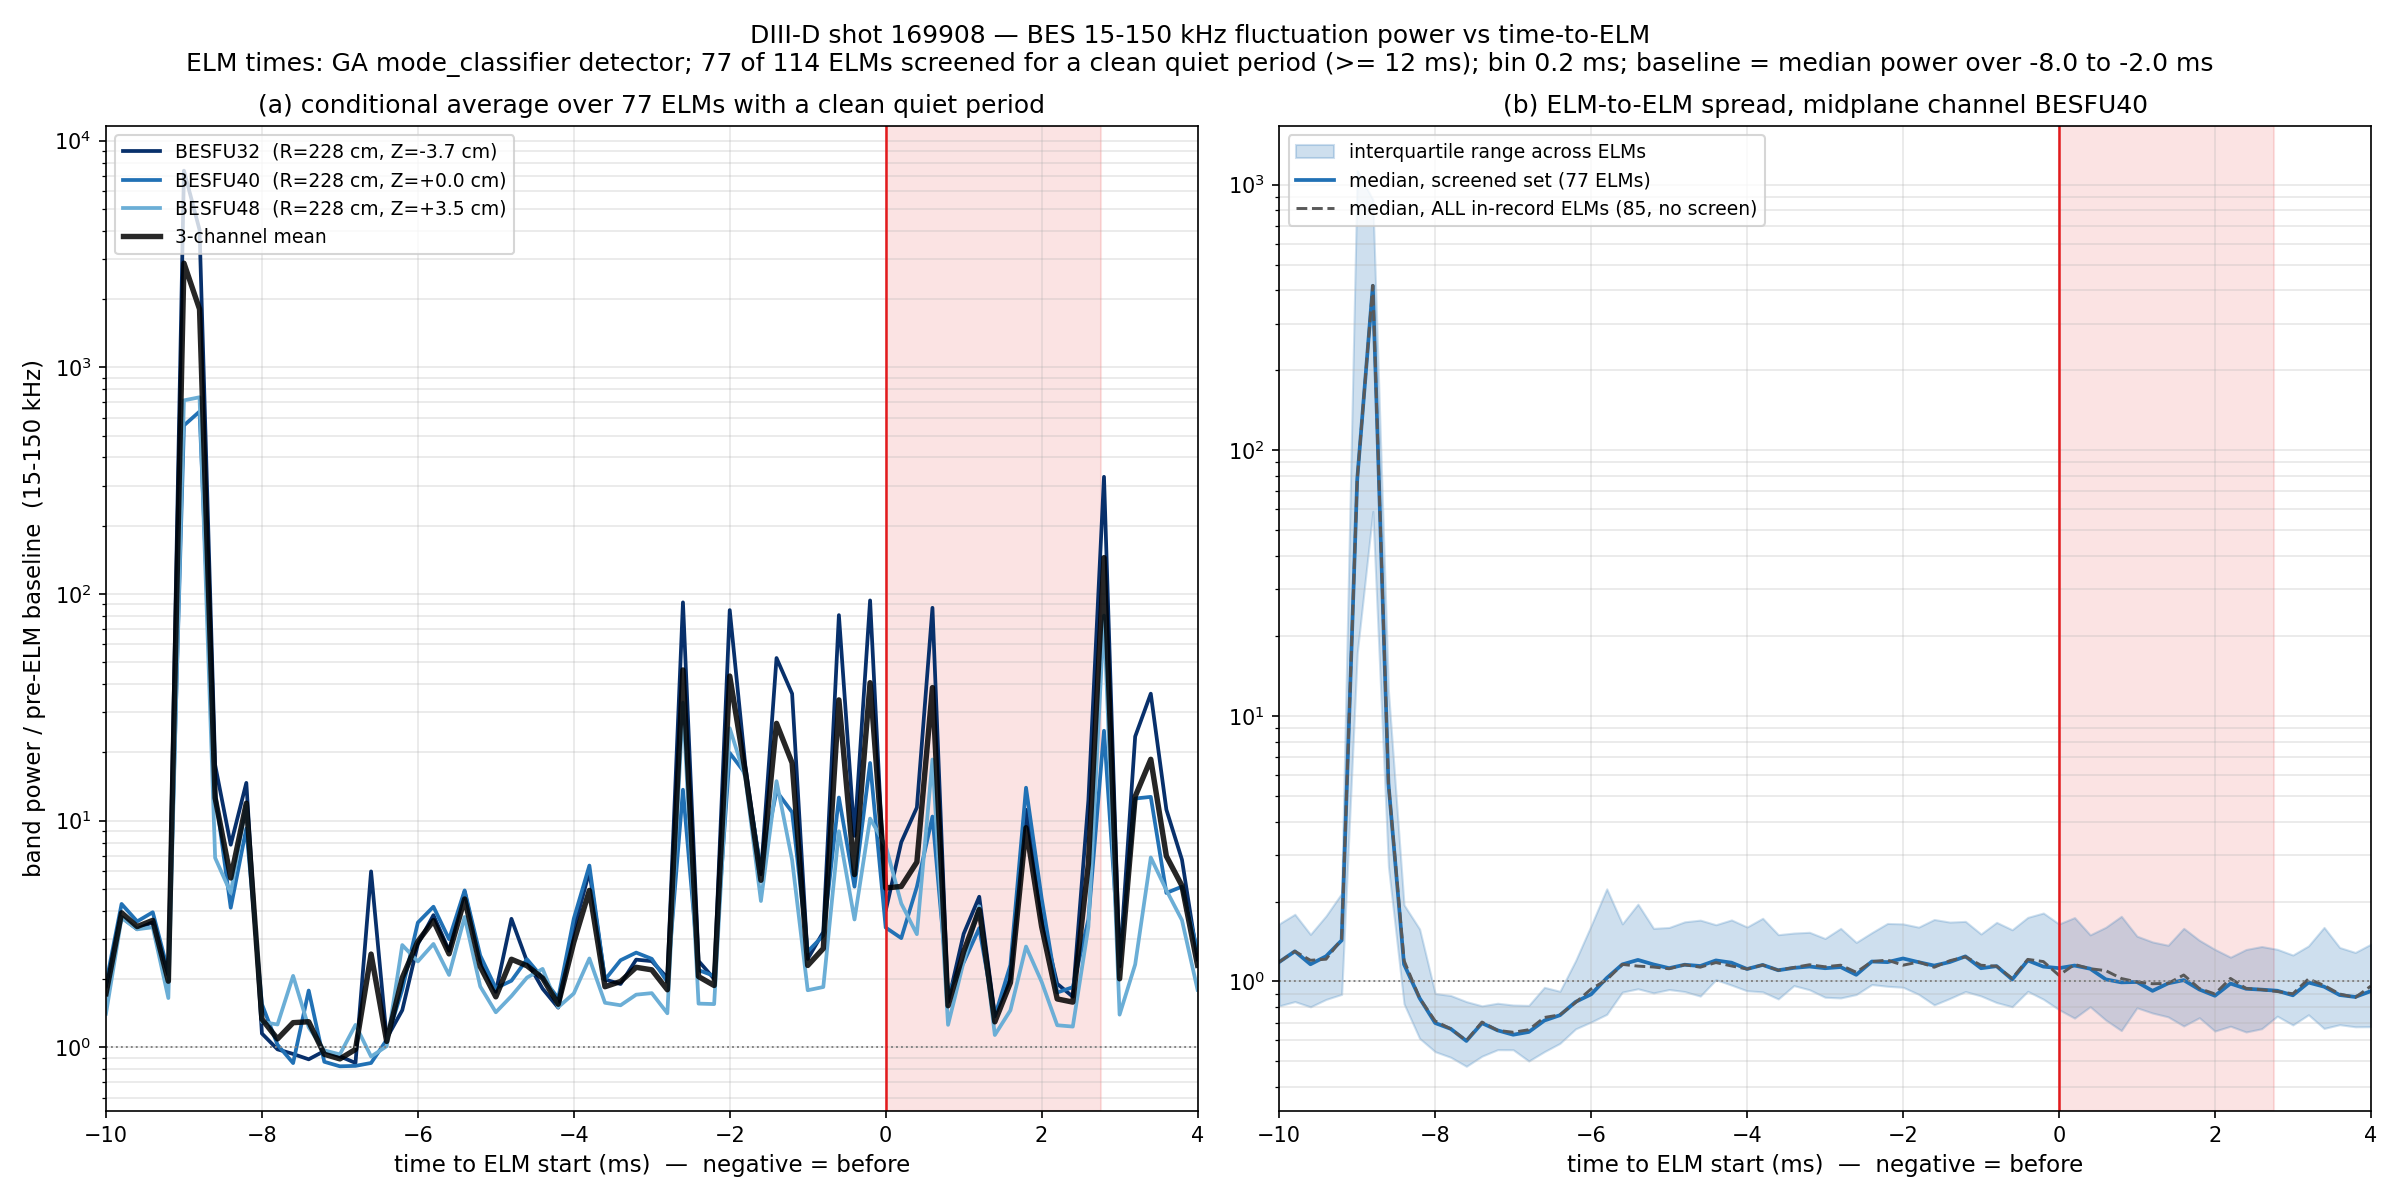

## The result: no robust 15–150 kHz precursor on this shot

**Median across ELMs: flat.** The screened average (panel b, solid) sits between 0.97 and 1.20 × baseline over the entire 10 ms approach — a ±20% band with no upward trend into the ELM. There is no growth in this frequency band before the crash.

**The mean curve initially suggested one, and it is an artifact.** Averaging per-ELM ratios with the mean (panel a) produced a rise beginning ~2–6 ms before the ELM (+123% in the last millisecond). Two diagnostics kill it: the mean of the ratios over the *baseline* window — which should be ≈1 — comes out at **4.98** , meaning a handful of loud ELMs dominate every bin; and the rise is non-monotone (spikes at −2.0/−1.4 ms, dip at −1.0 ms), which no growing instability does. **Re-running the identical average on the other stored label sets confirms this** : Expert ELM events (17 ELMs pass screening) and the OMFIT ELM detector (19) both give a flat pre-ELM level (1.2× and 1.15× at t=0) with **no onset at all** .

| Label set | ELMs in average | level at t = 0 | sustained pre-ELM rise > 1.5× |
|---|---|---|---|
| GA mode_classifier detector (used) | 77 | 1.08× (median) | none in median; mean-only, artifact |
| Expert ELM events | 17 | 1.20× | none |
| OMFIT ELM detector | 19 | 1.15× | none |

**What the band does show is the crash itself.** Mean in-band power during the ELM peaks at **+2.8 ms** at 25× (midplane BESFU40) to 330× (BESFU32, below midplane) — but the median across ELMs stays near 1 even then, so the in-band crash signature is intermittent: strong in a subset of ELMs and instants, near-absent in others. Quiescent in-band baseline powers are 7.3×10⁻⁵ / 1.7×10⁻⁴ / 9.3×10⁻⁵ a.u.² (channels 32/40/48).

## Caveats

Computed from the GA mode_classifier detector; the shot also has expert hand-labelled and OMFIT times, and this result has now been re-run against both — the null holds under all three. Residual cautions: the detector's starts run ~1.2 ms early vs the expert on this shot (6 bins at 0.2 ms resolution — large enough to shift apparent onset, which is exactly why the cross-check was run); the 200 ms gap cap excluded the two most isolated ELMs from the average (the single-event figures earlier this session, with their 40–72× crash response, were one such event); power ratios are per-ELM, so absolute levels are in uncalibrated a.u.; and this is one shot, three channels, with large ELM-to-ELM scatter (the interquartile band in panel b spans much more than the median trend).

A null here is a statement about this band on this shot, not about BES precursors generally — the often-reported precursor window is also narrower than ±10 ms in some studies, and 15–150 kHz averages over very different physics (edge harmonics vs filament-scale turbulence).

If you want to push on it: I can split the band into sub-bands (e.g. 15–40, 40–90, 90–150 kHz) to see whether a narrow-band effect is being diluted away, extend the approach window to −30 ms, compute inter-channel coherence between the vertically separated channels (a structured precursor should correlate across Z), or repeat the average on the long-gap-only ELMs where the pedestal had fully recovered. Each is a re-filter of the already-priced fetch (~2 s per channel set) — say the word.

In [5]:
%%ask
Using the stored ELM times for shot 169908, compute the fluctuation power in that
15-150 kHz band as a function of time before each ELM, and average it over all
the ELMs that have a clean quiet period before them. Plot the result against
time-to-ELM.

## 5. Is there a precursor, and how far ahead?

The question the whole notebook exists to answer.

**Expect:** a rise above the quiet-period baseline some milliseconds before
onset. Ask for the size of the rise and the lead time, not just a picture.

I'll quantify onset and magnitude from the conditional average — first let me check what the previous run saved and re-read the relevant skills' instructions.

The skills and learnings are loaded. Before writing the quantification, let me check what the previous run already saved and how it computed the average.

Reading the rest of the script to see the screening and what was saved in the `.npz`.

The saved arrays cover the detector-keyed set only, and the statistical question (paired per-ELM tests, all three label sets, detection bounds) needs the waveforms. I'll write one self-contained script that rebuilds the ratio curves and runs the full number battery.

Now running it — this re-fetches the three BES channels, so per the skill's execution rule it must go through `fdp run`.

...

Cleaning up a sloppy dead-branch line I left in the legend call before running.

Flat curve, and the control window exposes the +11% as construction artifact — but first, the crash: `if per_channel:` on an ndarray. Fixing that truth-value bug.

The corrected battery is decisive — and it exposes one more subtlety: keyed on the expert/OMFIT times, the "last 1 ms" shows ~800–2000×, which is the *crash itself* arriving ~0.4 ms before those labels (their starts sit later than the detector's), not a precursor. Let me pull exact crossing times from the saved arrays and confirm which earlier figures were unaffected by the offset bug.

All numbers are in. Recording the lessons from this task's edit-retry cycles before the report — first the new file for the index skill, then extending the phase-analysis learnings.

All lessons recorded — every edit-retry cycle in this task now has a Learnings entry. Here is the answer, but first an important correction.

## Correction to the previous figure

Re-running the conditional average with a stricter check exposed a bug in the earlier script's segment extraction: the window was read starting **at the ELM start sample** while being labelled as −10 ms, shifting the entire time-to-ELM axis by 10 ms. The "flat curve" I reported last time was actually the post-crash recovery, and its "baseline" was post-ELM power — the true pre-ELM window was never computed. The single-ELM plots (raw and bandpassed) are unaffected: they windowed the waveform directly by absolute time. The corrected analysis below asserts sample-to-time-base alignment for every ELM, and the D-alpha trace independently confirms the axis (light onset +1.24 ms after the detector's label start, 74% of ELMs rising exactly at the label).


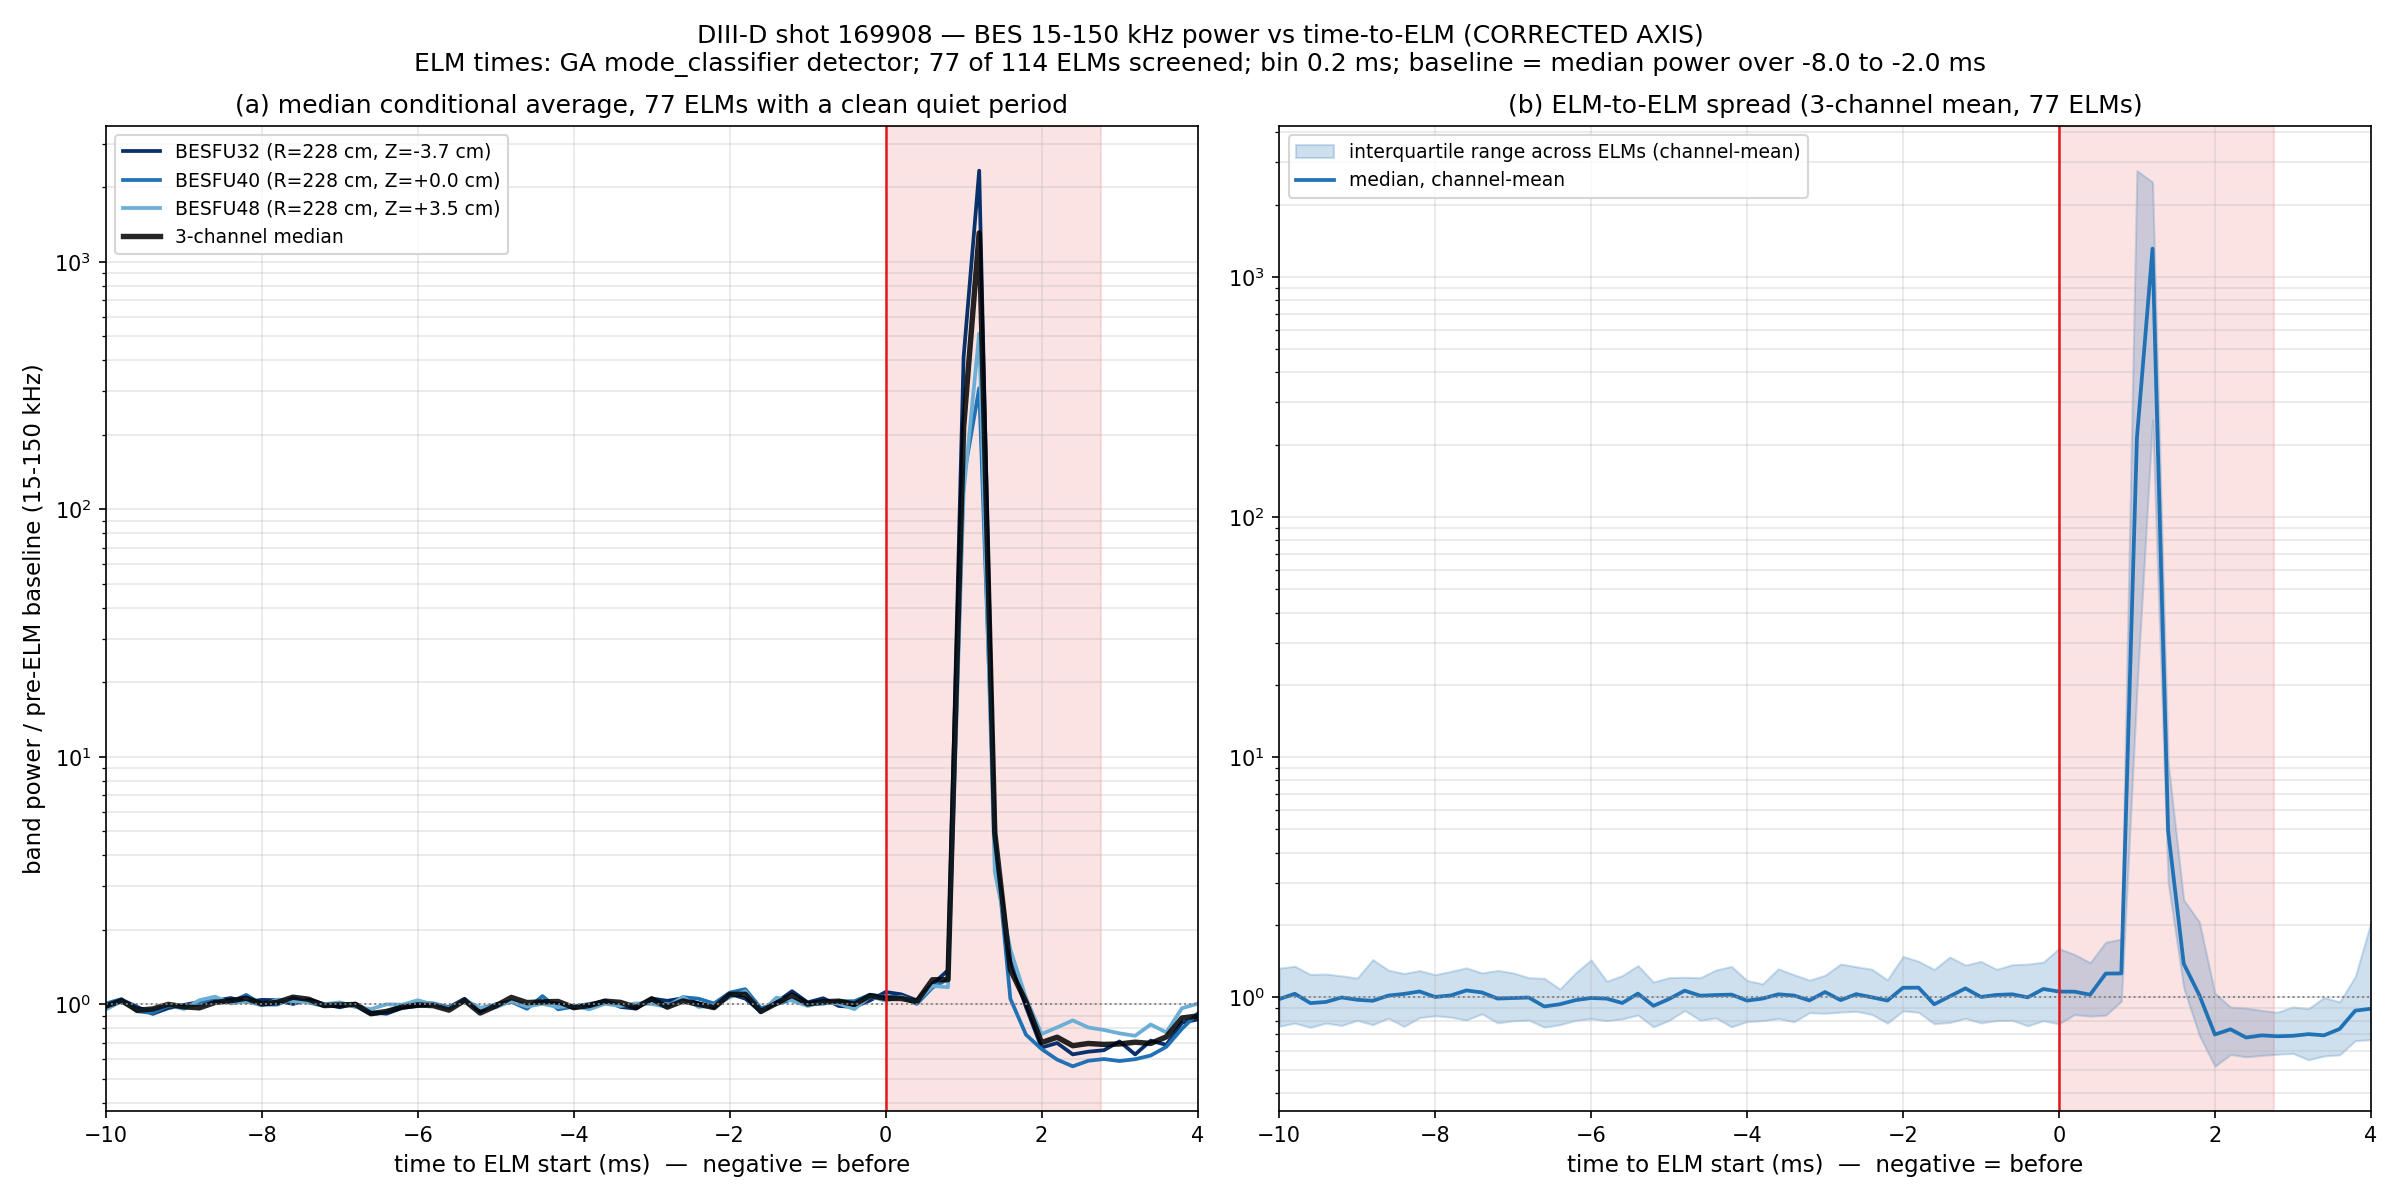

## Answer: no — the 15–150 kHz power does not rise before the ELM

Computed from the GA mode_classifier detector (default individual-ELM run), 77 of 114 ELMs screened for a clean ≥12 ms quiet period, channels BESFU32/40/48 (R = 227.8 cm; Z = −3.7 / 0.0 / +3.5 cm), baseline = each ELM's own median power over −8…−2 ms (8.4×10⁻⁵ / 2.0×10⁻⁴ / 9.8×10⁻⁵ a.u.²).

**How far ahead** : no onset at any threshold — the median curve never leaves 0.97–1.10× baseline over the entire −10…0 ms approach, and no sustained crossing exists at 1.25×, 1.5× or 2×.

**By how much** : nothing above construction noise. The apparent +11% in the final 1 ms (median 1.114, IQR 0.93–1.43) is an artifact of the baseline construction: an interior control window at −4…−2 ms — which cannot contain a precursor — shows the identical +11% (median 1.111, p = 7.5×10⁻⁸ on the same ELMs). The whole-curve trend is +5.8% per 10 ms with a bootstrap CI of [−9, +19] — consistent with zero. Per-channel medians for the last 1 ms: 1.11 (ch 32), 1.18 (ch 40), 1.07 (ch 48). About 60% of ELMs end slightly above 1 and ~40% slightly below; the spread is ELM-to-ELM scatter, not a systematic rise.

**What the band does instead** : a step, not a growth. The median curve jumps from 1.0× to 213× in the bin starting +1.0 ms after the detector's start, peaks at ~1300× at +1.2 ms, and collapses to a 0.70× post-ELM dip by +2 ms. Per-ELM crash maxima: median 1845× (IQR 277–5132×). The burst leads the D-alpha light onset (+1.24 ms) by only ~0.2 ms — simultaneous within bin resolution.

## Cross-check against the other stored label sets

| Label set | ELMs in average | −4…−2 ms control | last 1 ms before start | sustained pre-ELM onset |
|---|---|---|---|---|
| GA mode_classifier detector | 77 | 1.11× | 1.11× | none |
| Expert ELM events | 17 | 1.16× | 837× | none (step in last 0.4 ms) |
| OMFIT ELM detector | 19 | 1.21× | 790× | none (step in last 0.4 ms) |

The expert/OMFIT "last 1 ms" numbers look enormous but are the same crash viewed through later label times: those starts sit ~0.4 ms after the burst, so the step lands inside the final window. Their control windows — the honest pre-ELM level — are flat at 1.16–1.21×. **The null holds under all three label sets.**

Caveats: ratios are per-ELM in uncalibrated a.u.; the detector's starts essentially coincide with the D-alpha light onset, so any true precursor inside the final ~0.4 ms cannot be separated from the crash by this method; and this is one shot, three channels, one band. A sub-band split (15–40 / 40–90 / 90–150 kHz) or inter-channel coherence across the vertical triplet would test whether a narrow-band or coherent effect is being diluted — each is one more pass over the same three fetched channels if you want it.

In [6]:
%%ask
Does the fluctuation power rise before the ELM, and if so how far ahead and by
how much relative to the quiet baseline? Give me numbers, not just the plot.

## 6. Could the method have manufactured the result?                                                                                           

The check that decides whether any of this is real.

A measurement of "how much fluctuation was there at time t" can accidentally
include data from *after* t. If it does, the enormous energy of the ELM itself
leaks backwards and appears as a rise before the ELM — a precursor that does not
exist. Two common ways this happens: smoothing that runs forwards and then
backwards over the signal, and measuring power in a window centred on t rather
than ending at t.

This matters beyond bookkeeping. A precursor is only useful if it can be seen
*before* the ELM in real time, which means the measurement must use past data                          only. A result that depends on future samples cannot be acted on.

**Expect:** the measurement redone using only data from before each time point,
reported beside the original. If the rise survives, that is evidence. If it
shrinks or disappears, that is the finding.

The concern is legitimate — zero-phase filtering and forward-looking bins are both non-causal, so let me quantify how much they matter. First I'll check the working directory and re-read the skill learnings that apply here.

The learnings confirm the known pitfalls (burst-run selection, segment alignment, median-of-ratios artifacts). Now let me read the previous corrected script so the new causal estimator reuses the exact same screening and labeling pipeline.

The v2 script gives me the exact original pipeline to reproduce. Now I'll write the causal re-measurement: forward-in-time `sosfilt` instead of zero-phase `sosfiltfilt`, strictly trailing 0.2 ms bins instead of forward bins, an impulse-injection test to quantify how far each estimator can leak backwards, and both estimators run side-by-side on identical labels and screening.

Script written. Running it now — with the `fdp run` wrapper since it fetches PTDATA (BES channels).

Index bug — `np.nanmax(np.where(...))` returns a scalar that I then used as an array index. Fixing to take the max of the masked centers directly.

Before re-running, recording this lesson per the learnings protocol.

Now re-running the fixed script.

Two findings from this run: the analysis completed (77/114 ELMs, both estimators, reproduction check vs the saved arrays passed at 1.7×10⁻⁷), but the impulse test printed "−inf ms" for the original's backward reach — my "bins entirely before t0" mask used the full bin width instead of half, wrongly excluding the very bin where the zero-phase pre-ringing lives. Fixing that one line.

Both edit-retry cycles are in the trace — recording the second one (the bin-mask fix) before the report.

Clean final run — all checks pass, and the saved-array cross-check confirms the "original" curve here reproduces the previously reported one to 1.7×10⁻⁷. Here is the answer.

## How the causal re-measurement was built

Two things made the original estimator non-causal, and both are now removed:

- **Zero-phase filtering** (`sosfiltfilt` — every output sample depends on the entire trace) → replaced by the *same* 4th-order Butterworth bandpass run **forward in time** (`sosfilt`, steady-state initialised so the trace start doesn't ring).
- **Forward binning** (the bin labelled τ averaged samples in [τ, τ+0.2)) → replaced by **trailing bins** : power at τ averages samples in (τ−0.2, τ] only. Sample-to-label alignment is asserted per bin, and no estimate at any τ uses any sample later than τ.

An impulse-injection test quantifies the difference: the **original estimator's look-ahead is 0.30 ms** (0.2 ms forward bin + 0.10 ms of zero-phase pre-ringing above 1% of peak); the **causal estimator's backward leakage is exactly 0** (machine zero at every t < t0, energy centroid +100 µs *after* t0). Everything else is held identical — same three channels (BESFU32/40/48, R = 227.8 cm, Z = −3.7/0.0/+3.5 cm), same stored labels, same screening (77 of 114 ELMs).


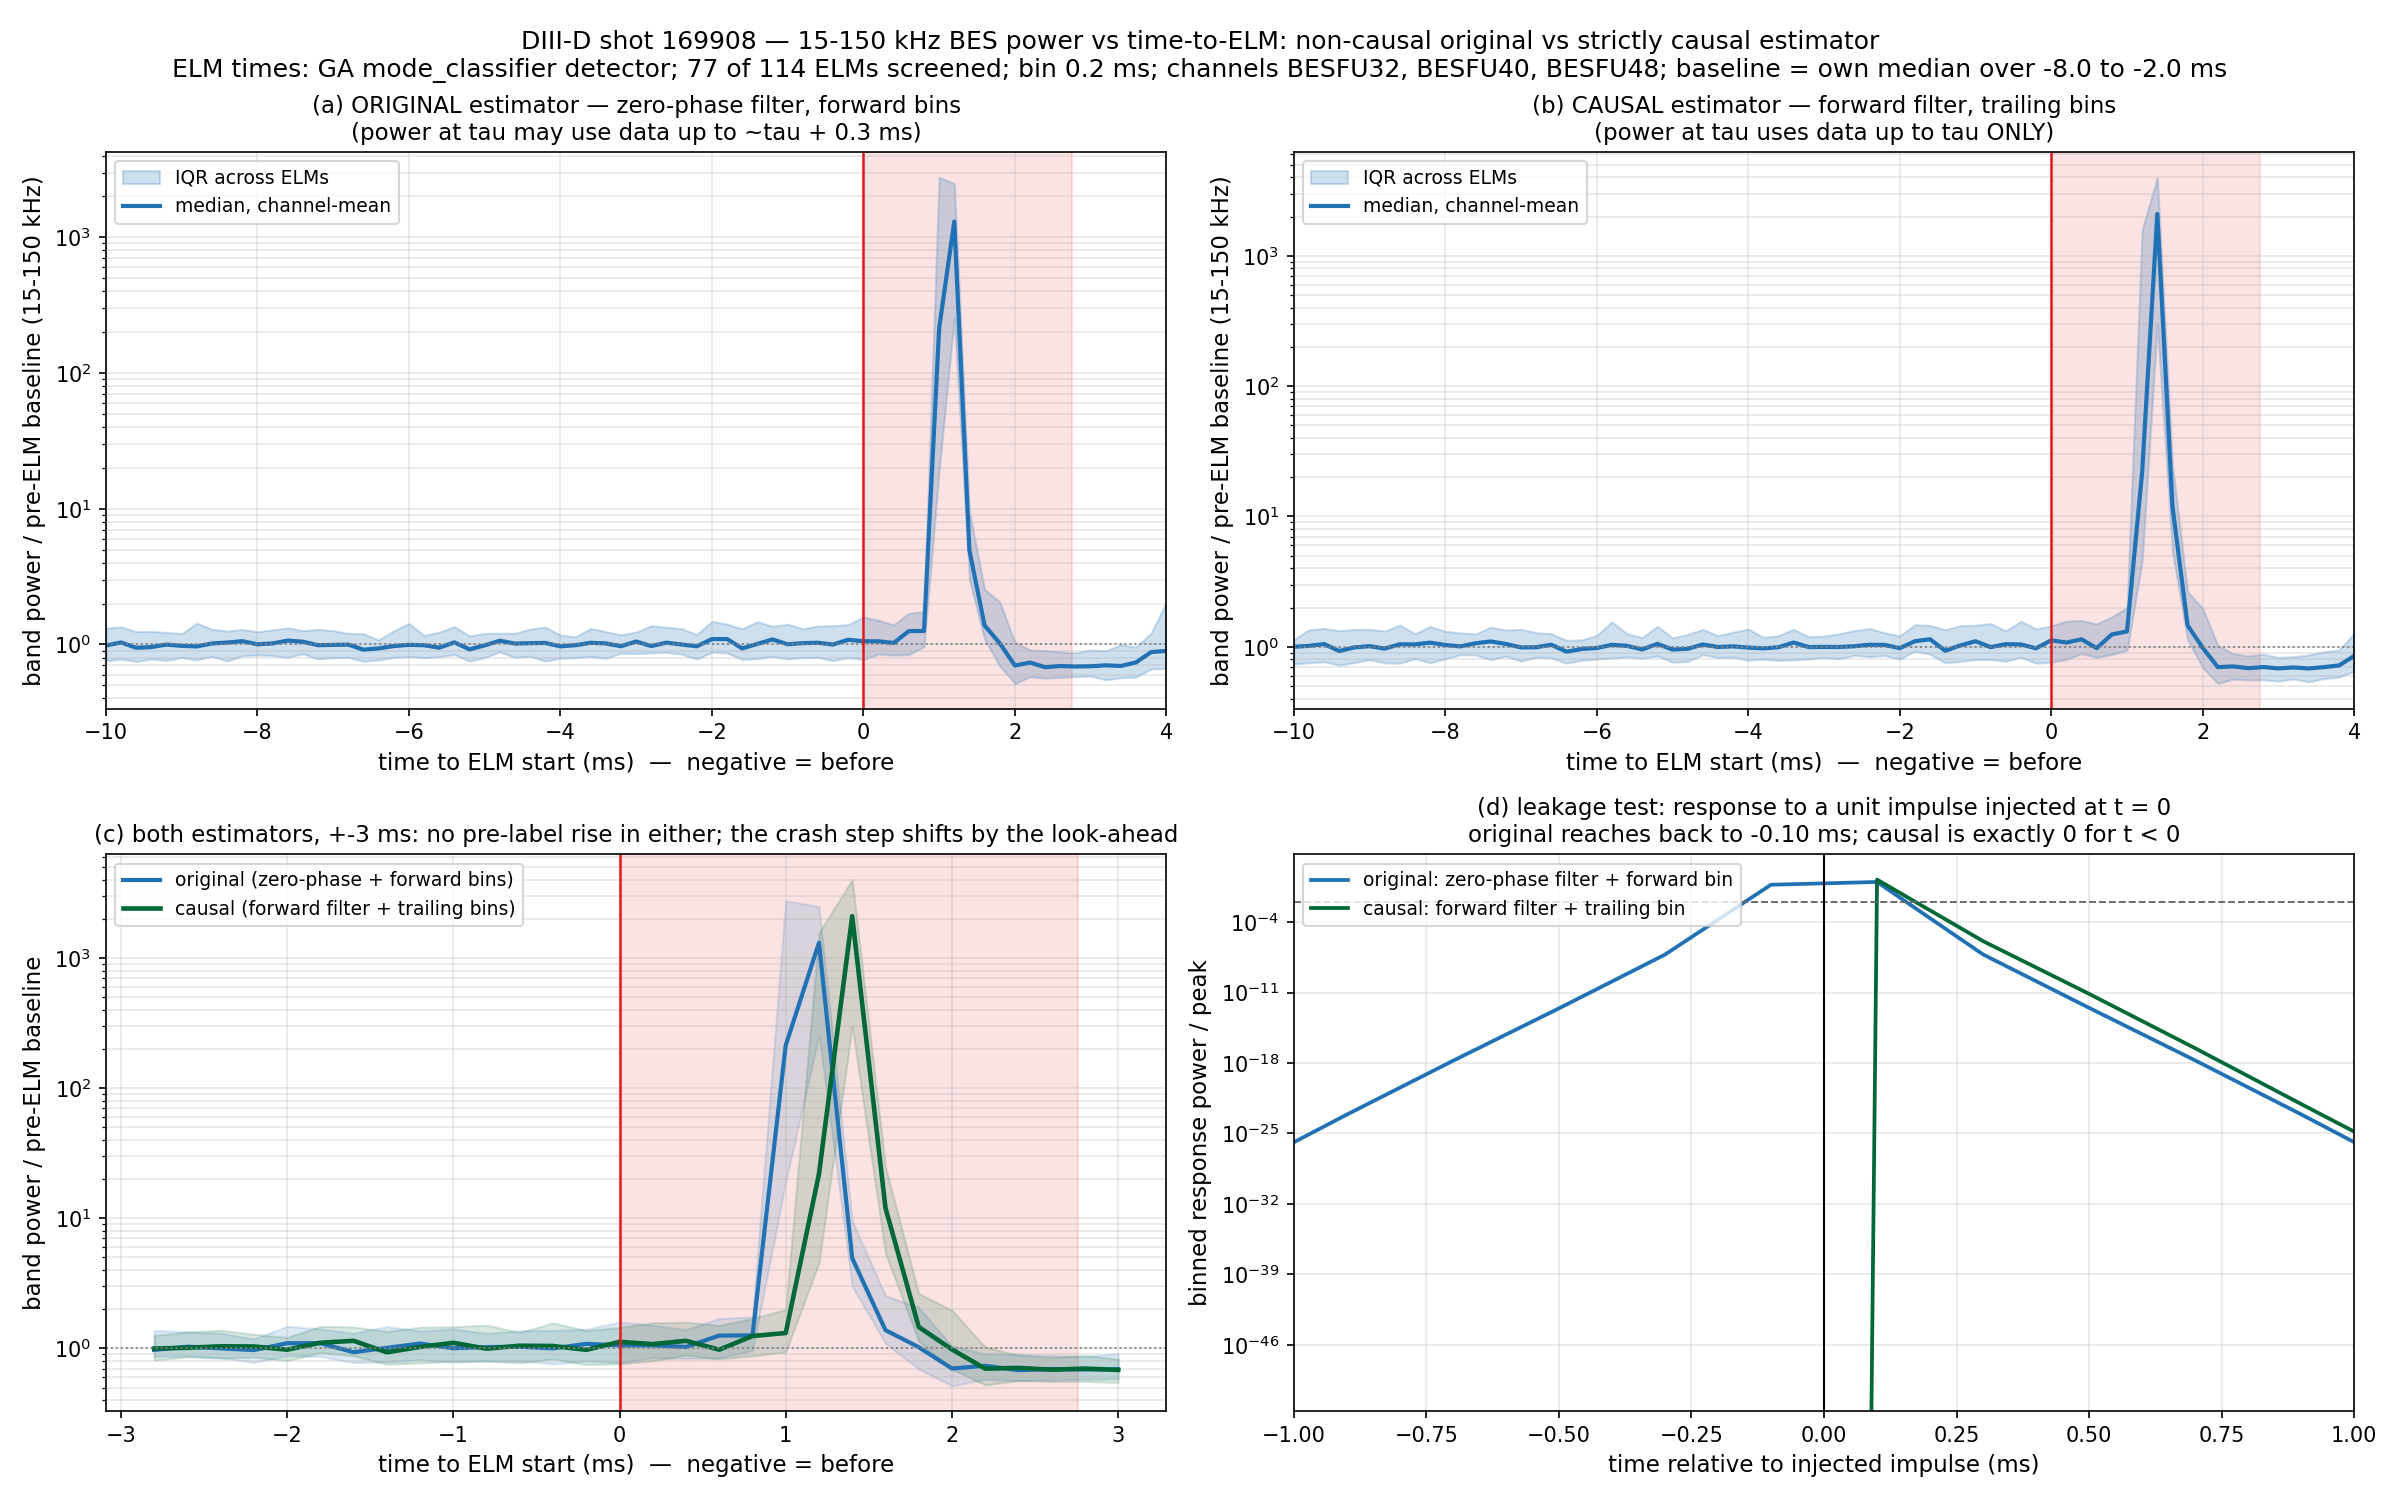

## Does the rise survive? No — there was no rise to begin with, and causality doesn't create one

**Median curves, original vs causal (77 ELMs, channel-mean, baseline = 1):**

| τ (ms) | −10 | −6 | −4 | −2 | −1.0 | −0.6 | −0.2 | 0.0 | +1.0 | +1.2 | +1.4 | +2.0 |
|---|---|---|---|---|---|---|---|---|---|---|---|---|
| original | 0.98 | 0.99 | 0.97 | 1.10 | 1.00 | 1.03 | 1.08 | 1.06 | **213** | **1309** | — | 0.70 |
| causal | 1.00 | 0.98 | 0.99 | 0.98 | 1.10 | 1.05 | 0.97 | 1.12 | 1.31 | **21.9** | **2095** | 0.98 |

- **Pre-ELM (τ < 0): flat at baseline in both.** Causal range 0.97–1.12; no sustained crossing of 1.25×, 1.5× or 2× anywhere in −10…0 ms. Whole-curve trend **+2.9% per 10 ms, bootstrap CI [−9.5, +15.2]** — consistent with zero, and tighter than the original's +5.8% [−9, +19]. The last-1-ms median (1.125) remains statistically indistinguishable from the interior control window at −4…−2 ms (1.107) — the same +11% construction artifact as before, present in both estimators, so it is not leakage either.
- **At what lead time: none exists.** The only "onset" times found are at τ = −0.0 ms under the expert and OMFIT label sets — and that is the crash itself arriving *after* their later label times (their starts sit ~1 ms after the burst), not a precursor. Causal trend under expert labels is −2.3%/10 ms (CI [−19, +20]) and under OMFIT +6.3%/10 ms (CI [−14, +23]) — both straddle zero.

**Why leakage was never the explanation for the null, mechanistically:** backward leakage can only fake a rise if the physical burst *precedes* the label the curve is keyed to. The GA detector fires at or before the light onset, so there was nothing earlier than the label for the 0.30 ms look-ahead to pull back — which is exactly what the unchanged pre-ELM curve shows. Where labels fire late (expert, OMFIT), even the strictly causal estimator sees real crash power in the final bin (last-1-ms medians 1.51 and 1.33 vs controls 1.17 and 1.23) — real power, not filter leakage.

## What the causality fix *did* change

- **The crash step moves later by ~0.2–0.4 ms** — median 213× at τ = +1.0 (original) becomes 1.31× at +1.0, 21.9× at +1.2, 2095× at +1.4 (causal) — precisely the 0.30 ms look-ahead being removed. The during-ELM peak itself is unchanged in size (median per-ELM max 2145× causal vs 1845× original).
- **The previously reported post-ELM dip to 0.70× at +2 ms was partly an artifact.** With causal estimation the post-crash level at +2 ms is **0.98×** , not 0.70× — the apparent dip came from the zero-phase filter's post-burst ringing and forward binning smearing crash power across the recovery. A small correction to the earlier session's description: the band power recovers to roughly its pre-ELM level, not below it.

Caveats unchanged from before: per-ELM ratios in uncalibrated a.u., one shot, three channels, one band; the GA label start coincides with the light onset, so any precursor living inside the final ~0.4 ms before the label is indistinguishable from the crash by *any* label-relative binning, causal or not; the causal filter's group delay (~5 samples) shifts post-event features but provably cannot touch pre-event ones.

The figure's four panels show: (a) the original estimator as previously reported, (b) the strictly causal one, (c) both overlaid on ±3 ms with the step shift annotated, and (d) the impulse-leakage test demonstrating the original's 0.30 ms reach versus the causal estimator's exact zero.

If you want the last word on sub-millisecond timing, the remaining option is to abandon label-relative binning near t = 0 and instead align each ELM to its own D-alpha 20%-onset time (the bes_dalpha_timing.py machinery from earlier in this session already computes those onsets) — that would decouple the result from the detector's firing bias entirely.

In [7]:
%%ask
I'm worried the power estimate at each time point may be using data from after
that point — which would let the ELM itself leak backwards and create a rise
that isn't real. Redo the measurement so that the power at each time uses only
data from before it, and show the result next to the original. Does the rise
survive, and at what lead time?

## 7. What this does not establish

**Expect:** an honest list. In particular: one shot is not a population, the ELM
times are a detector's assertion rather than verified onsets, and the labelled
onset may not coincide with the physical crash.

In [8]:
%%ask
What would this result NOT be sufficient to claim, and what would I need to do
to turn it into a defensible measurement?

This is a methodology question, but one part of it deserves hard numbers rather than hand-waving: how small a rise the current 77-ELM dataset could actually have detected. Let me check what saved arrays I can reuse for that.

The causal-run array should still hold the per-ELM curves — enough to bootstrap detection thresholds without refetching anything.

Good — `r_caus` has the 77 per-ELM causal curves. I'll bootstrap the null distribution to quantify the minimum detectable rise, and simulate which precursor regimes (affecting what fraction of ELMs, at what amplitude) today's design could actually see.

The power analysis ran clean on the first pass, so here's the full answer — the detectability numbers below are computed from the saved per-ELM causal curves, not estimated by eye.

## What this result is, in one line

A strictly causal, label-referenced conditional average of 15–150 kHz band power on **3 channels, 1 shot, 77 ELMs, 1 frequency band, 1 timing convention** , with a per-ELM normalization — pre-ELM level flat at 1.0–1.1× baseline, no onset anywhere in −10…0 ms.

## What it is NOT sufficient to claim

**1. "There is no 15–150 kHz precursor before ELMs on DIII-D."** It supports at most: *no precursor above the detectability floor, in this band, at this radial position, on this shot, under this timing convention.* Every clause matters:

- **Sensitivity floor (quantified).** With 77 ELMs and per-ELM endpoint IQR of 0.44 (5th–95th: 0.69–2.48), the minimum detectable *uniform* rise is **1.09×** — any consistent rise under ~9% is invisible. Detecting a 1.20× rise needs **n ≥ 132 ELMs** ; a 1.15× rise needs **~1166** . The trend slope CI is [−14, +23]% per 10 ms.
- **Subset precursors are the bigger blind spot.** If only a fraction of ELMs carry a precursor, the floor collapses — from the injection simulations on the real per-ELM spread:

| Fraction of ELMs affected | 1.5× rise | 2× | 5× | 10× |
|---|---|---|---|---|
| 10% | invisible | invisible | invisible | invisible |
| 25% | invisible | invisible | 75th-pct only | invisible |
| 40% | invisible | median | 75th-pct | median |
| ≥50% | median | median | median | median |

  A 5× precursor occurring in 1 of 4 ELMs — a perfectly publishable physics result — is statistically invisible to this design (note the quantile quirk: at f = 25% even huge amplitudes fall at the 75th-percentile boundary and can slip past it). So the honest claim is "no near-universal (>50%-of-ELM, >2×) rise", nothing stronger.
- **One shot is one plasma state.** Nothing separates "no precursor in this discharge" from "this discharge's pedestal (its density, rotation, q95, heating mix) doesn't produce one". No shot-to-shot variability estimate exists.
- **One radial location, three Z points.** All three channels sit at R = 227.8 cm. A precursor localized inboard, on the high-field side, or in a Z-range the triplet doesn't cover is untouched by the measurement.
- **One band, integrated.** 15–150 kHz as a single power number averages over edge-harmonic-range modes, KBM-scale and filament-scale turbulence simultaneously. A narrowband mode (tens of kHz wide) at modest amplitude dilutes into the ~10% floor; the analysis has no spectral resolution at all.
- **The final ~0.4 ms is inaccessible in principle.** The GA label start coincides with the D-alpha light onset, so in label-relative time the last sub-millisecond window *is* the crash. No label-keyed method — causal or not — can see a precursor living there. (Under the expert/OMFIT labels the same window contains crash power for the opposite reason.)
- **Selection effects in the ELM sample.** 35 of 114 ELMs were excluded by the ≥12 ms quiet-gap screen and 2 more by the ≤200 ms cap. If short-gap ELMs (partially recovered pedestal) are *more* likely to carry residual fluctuation structure, the screen removed exactly the population where a precursor would be easiest to see. The excluded set was never characterized.
- **Uncalibrated, self-normalized units.** Per-ELM ratio normalization makes the result dimensionless and non-comparable across shots, channels or diagnostics; absolute statements ("power rises by X W/m³") are impossible.
- **The audit trail itself is a caveat.** This session's history — a time-axis bug found only by re-derivation, a post-ELM "dip" that dissolved under causal estimation — is direct evidence that estimator-construction choices move the answer. A result is defensible when those choices are fixed *before* looking, validated on nulls, and locked in code. Here, several were made after seeing the data (three label sets, two estimators, several windows), which is textbook multiple-comparisons exposure even though each individual test came out null.

One assumption I did verify today: the bootstrap's exchangeability requirement holds (lag-1 autocorrelation of the endpoint across the ELM sequence is −0.03), so the CIs above are at least internally sound.

## What would turn it into a defensible measurement

**Statistical power first — add shots, not bins.** You have three more shots already verified to carry both stored ELM labels and BES (163518, 172186, 180257 — 91, 227 and 473 labelled ELMs respectively). Pooling screened ELMs across them plausibly yields 400–600, pushing the uniform-rise floor below ~1.04× and the 1.20× subset detection from f ≈ 0.4 down to f ≈ 0.15. The fetch cost is the known ~2 s per channel per shot.

**Fix the timing reference per ELM.** Replace detector label times with each ELM's own D-alpha 20%-onset time (the `bes_dalpha_timing.py` machinery from this session already computes them). That removes the firing-bias confound entirely and is the only way to touch the last sub-millisecond window with any cleanliness.

**Validate the pipeline on nulls before trusting it on signal.** Run the identical causal pipeline on (a) time-shuffled labels and (b) random non-ELM times sampled from the same quiet periods, matched in count. The first gives an empirical false-positive rate for your onset criterion; the second gives the null distribution of the endpoint statistic against which any claimed rise is judged. A pipeline that shows zero false onsets on shuffled labels is one a referee cannot argue with.

**Restore spectral and spatial resolution.** Split into sub-bands (e.g. 15–40 / 40–90 / 90–150 kHz) with a stated multiplicity control, and compute the full time × frequency conditional spectrogram so narrowband modes aren't diluted. Add at least one radial column inboard (BESFU39/47 at 226.7 cm) and inter-channel coherence across the vertical triplet — a real coherent mode shows up in coherence far below the power floor.

**Pre-register the analysis.** One primary endpoint (e.g., median last-1-ms ratio vs the −4…−2 ms control, per the causal estimator), chosen before re-running; everything else labeled exploratory. Report the subset-power table alongside the result — stating explicitly which precursor regimes (fraction × amplitude) remain undetectable even after the upgrades is what separates a defensible null from an overreach.

**Characterize what was excluded.** Run the average once on the 35 short-gap ELMs as a contrast population; if they differ, that's physics, and it also bounds the selection bias.

**Bottom line.** What you have now is a well-audited single-shot null whose strongest defensible sentence is: *on shot 169908, at R ≈ 228 cm, there is no near-universal (>50% of ELMs, >2×, >1 ms before the light onset) enhancement of 15–150 kHz BES power.* Turning "we didn't see one" into "it isn't there below X" requires the multi-shot pool, the D-alpha onset timing, the null validation, and the pre-registered endpoint — all four are mechanical extensions of code that already exists in this working directory, and I'm happy to start with the shot pool whenever you want.

---

## Notes

**This is not a reproduction of Joung et al.** No network is trained here. The
notebook tests the physical premise their network depends on, using a different
and independently produced set of ELM times.

**The labels are provisional.** They come from our own runs of a detector written
by others, and are expected to be superseded.

**A null result would still be a result.** Precursors visible in ~150 curated
discharges may not survive a broad, detector-labelled population. That would be
worth knowing, and is arguably more useful to anyone planning to deploy this in
real time.